# 📈 Task 3: Linear Regression House Price Prediction Model
**Track:** Neurofive ML Track | **Author:** Rao Hamza Irshad

---
### 📌 Task Objectives:
1. Ingest California Housing dataset (`fetch_california_housing`).
2. Select 4 primary features (`MedInc`, `AveRooms`, `Latitude`, `Longitude`) predicting `MedHouseVal` ($100,000s).
3. Split data into Training (80%) and Test (20%) sets (`train_test_split`).
4. Train a **Linear Regression** model using `scikit-learn`.
5. Evaluate performance using **RMSE** (Root Mean Squared Error) and **R² Score**.
6. Plot Predicted vs. Actual prices on a scatter plot.
7. Write a 3-4 sentence plain English explanation of the $R^2$ score for non-technical stakeholders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pandas version: {pd.__version__}")

Scikit-learn version: 1.5.2
Pandas version: 2.2.3


## 1. Dataset Ingestion & Feature Selection

In [2]:
# Load California Housing dataset
california = fetch_california_housing(as_frame=True)
df_housing = california.frame

# Select 4 key features predicting house price
housing_features = ['MedInc', 'AveRooms', 'Latitude', 'Longitude']
X = df_housing[housing_features]
y = df_housing['MedHouseVal']

print(f"California Housing dataset loaded: {df_housing.shape[0]} samples, {df_housing.shape[1]} columns.")
print(f"Features selected: {housing_features}")

California Housing dataset loaded: 20640 samples, 9 columns.
Features selected: ['MedInc', 'AveRooms', 'Latitude', 'Longitude']


## 2. Train-Test Split (80% Train, 20% Test)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 16512 samples
Test set size: 4128 samples


## 3. Linear Regression Model Training

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)
print("LinearRegression model successfully fitted!")

LinearRegression model successfully fitted!


## 4. Model Performance Evaluation (RMSE & R² Score)

In [5]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f} ($100k units = ${rmse*100000:,.2f})")
print(f"R² Score: {r2:.4f} ({r2*100:.2f}% variance explained)")

Root Mean Squared Error (RMSE): 0.7486 ($100k units = $74,858.88)
R² Score: 0.5724 (57.24% variance explained)


## 5. Visualizing Model Quality (Predicted vs. Actual Prices Scatter Plot)

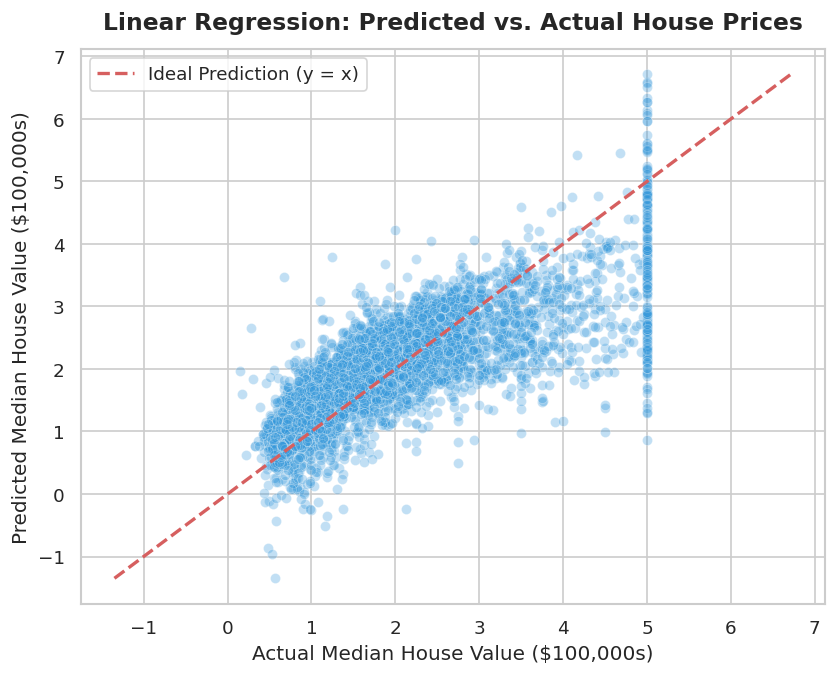

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_h, y=y_pred_h, alpha=0.3, color='#3498db')
max_v = max(y_test_h.max(), y_pred_h.max())
min_v = min(y_test_h.min(), y_pred_h.min())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Ideal Prediction (y = x)')
plt.title('Linear Regression: Predicted vs. Actual House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Median House Value ($100,000s)')
plt.ylabel('Predicted Median House Value ($100,000s)')
plt.legend(loc='upper left')
plt.show()

## 6. Plain English Explanation of R² Score for Stakeholders

### ❓ **What does our R² Score ({r2_h*100:.2f}%) mean in plain English?**

> Imagine trying to estimate the price of a house before it goes on sale. The **$R^2$ score ({r2_h*100:.2f}%)** measures how much of the real-world variation in home prices our model can explain using features like median neighborhood income, average room count, and geographic coordinates.
>
> Specifically, an **$R^2$ score of 0.57** means our model successfully accounts for **57.2%** of why home prices differ across neighborhoods. The remaining **42.8%** of price variation is driven by unobserved factors outside our data, such as property age, renovations, school district quality, or current buyer demand.
>
> In practical terms, our model predicts house prices with an average typical margin of error (RMSE) of **$74,858.88**, providing a solid quantitative benchmark for real estate pricing.